# Graph Convolutional Networks

*August 4 2026*  
*Training Workshop: Introduction to Deep Graph Learning*  
*Ingo Scholtes, CAIDAS, Julius-Maximilians-Universität Würzburg (JMU), Germany*  

Building on the Neural Message Passing layer implemented in the previous notebook, we now implement a full-fledged graph convolutional neural network and apply it to synthetic and empirical example networks.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch_geometric
from matplotlib import pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import TruncatedSVD

import pathpyG as pp

plt.style.use('default')
sns.set_style("whitegrid")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Running on', device)

Running on cuda


We use a simple example for a network with two strong communities from the lecture, which define our ground truth (binary) node classes. In fact, these two node classes can be easily predicted based on the topology of the graph alone, i.e. here we do not need any node features.

In [ ]:
n = 50

random_1 = pp.algorithms.generative_models.watts_strogatz(n=n, s=4, p=0.01, mapping=pp.IndexMap([str(x) for x in range(n)]), undirected=True)
random_1.data.y = torch.tensor([0]*n)

random_2 = pp.algorithms.generative_models.watts_strogatz(n=n, s=4, p=0.01, mapping=pp.IndexMap([str(x+1*n) for x in range(n)]), undirected=True)
random_2.data.y = torch.tensor([1]*n)

colors =  {}
for v in random_1.nodes:
    colors[v] = 'orange'
for v in random_2.nodes:
    colors[v] = 'blue'

network = random_1 + random_2
network = network.to_undirected()
# to_undirected() only preserves edge_index/x/edge_attr, so we have to restore the node labels
network.data.y = torch.cat([random_1.data.y, random_2.data.y])

# randomly update src and tgt in network.edge_index so that link source in random_1 to target in random_2 and vice-versa
src_indices = torch.where(network.data.y < 1)[0]
tgt_indices = torch.where(network.data.y >= 1)[0]
num_edges_to_update = 2
edge_indices_to_update = np.random.choice(network.data.edge_index.shape[1], num_edges_to_update, replace=False)
for edge_index in edge_indices_to_update:
    src, tgt = network.data.edge_index[:, edge_index]
    if src in src_indices and tgt in src_indices:
        new_tgt = np.random.choice(tgt_indices.cpu().numpy())
        network.data.edge_index[1, edge_index] = new_tgt
    elif src in tgt_indices and tgt in tgt_indices:
        new_src = np.random.choice(src_indices.cpu().numpy())
        network.data.edge_index[0, edge_index] = new_src


pp.plot(network, edge_color='gray', node_color = colors);

We also add a one-hot encoding of the nodes as additional feature:

In [3]:
network.data.x = torch.eye(network.n, dtype=torch.float32)
network.data.y.unsqueeze_(-1)

tensor([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],

We now implement the graph convolutional network (GCN). We first reuse the implementation of the neural message passing layer from the previous notebook:

In [4]:
class GraphConvolution(torch_geometric.nn.MessagePassing):

    def __init__(self, in_ch, out_ch):
        super().__init__(aggr='add')

        # this linear function is used to transform node features 
        # into messages that are then "sent" to neighbors
        self.linear = torch.nn.Linear(in_ch, out_ch)
        
    def forward(self, x, edge_index):
        """This function uses the edges captured in edge_index, performs
        the graph convolution function according to (Kipf, Welling 2017)
        and propagates the transformed features along the edges of the graph
        """
        # by adding self-loops, we ensure that aggregated messages from neighbors 
        # are combined with information from the node itself
        # this corresponds to matrix $\tilde{A}$ in (Kipf, Welling 2017)
        edge_index, _ = torch_geometric.utils.add_self_loops(edge_index, num_nodes=x.size(0))

        # we linearly transform the features of *all* nodes stored in x
        x = self.linear(x)

        # extract source and target nodes of all edges
        source, target = edge_index
        
        # compute the (in-)degrees $d_i$ of source nodes
        deg = torch_geometric.utils.degree(target, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0

        # with this, the normalization to be applied in the propagation step can be expressed as
        # this corresponds to D^{-0.5} A * D^{-0.5} in (Kipf, Welling 2017)
        norm = deg_inv_sqrt[source] * deg_inv_sqrt[target]
        
        # the propagate function propagates messages along the edges of the graph
        # this function internally calls the functions: message(), aggregate() and update()
        # the normalization is applied in the message() function
        return self.propagate(edge_index, x=x, norm=norm)
    
    def message(self, x_j, norm):
        # x_j is a so-called **lifted** tensor which contains the source node features of each edge, 
        # i.e. it has a shape (m, out_ch) where m is the number of edges

        # a call to view(-1, 1) returns a reshaped tensor, where the second dimension 
        # is one and the first dimension is inferred automatically
        return norm.view(-1,1) * x_j

As explained before, this class implements the convolution layer based on a single round of message passing. The parameter `in_ch` must correspond to the dimensionality of the node feature vector. By changing the parameter `out_ch` we can use a linear transformation that maps node features to a higher-dimensional vector, which - analogy to the neural graph embeddings introduced in Lecture 10 - we can view as hidden layer that contains a latent representation of nodes.

We eventually map those latent node representations to the output classes for all nodes. We apply a non-linear transformation to node features and add a second graph convolutional layer, i.e. we run a second round of message passing, where the messages now contain latent representations of nodes that will be used for the classification. The second convolutional layer generates the output for our binary classification problem, i.e. the probability of class 1.

In [5]:
class GCN(torch.nn.Module):

    def __init__(self, data: torch_geometric.data.Data, out_ch, hidden_dim=16):
        super().__init__()

        # first convolution layer 
        self.input_to_hidden = GraphConvolution(data.num_node_features, hidden_dim)

        # second convolution layer
        self.hidden_to_output =  GraphConvolution(hidden_dim, out_ch)
        
    def forward(self, x, edge_index):
        
        # first graph convolution -> map nodes to representations in hidden_dim dimensions
        x = self.input_to_hidden(x, edge_index)

        # non-linear activation function
        x = torch.sigmoid(x)

        # second graph convolution -> maps node representations to output classes
        x = self.hidden_to_output(x, edge_index)

        # output class probabilities
        return torch.sigmoid(x)

We are now ready to apply our model to our example. We use a hidden layer to learn a latent node representations in a 16-dimensional space. Due to the use of the one-hot-encoding as node features, each node has 100 features:

In [6]:
model = GCN(network.data, out_ch=1, hidden_dim=16)

Let's inspect the parameters of our Graph Convolutional Network with 16 hidden dimensions and two graph convolution layers, where the first layer maps the features of the 100 nodes to 16 hidden dimensions and the second layer maps the 16 hidden dimensions to one output per node, that is interpreted as a class probability.

In the first graph convolution layer, a linear transformation is applied in the message passing and we map the 100-dimensional node features of nodes to 16 dimensions in the first hidden layer. In other words, each node feature is passed through the same linear layer with 100 inputs and 16 outputs. This translates to a $16 \times 100$ weight matrix with additional 16 bias terms. 

In [7]:
params = [x for x in model.input_to_hidden.parameters()]
print(params[0].shape)
print(params[1].shape)

torch.Size([16, 100])
torch.Size([16])


In the second layer, we apply a linear layer that maps the 16 hidden dimensions for each node to a single output dimension, that we will interpret as probability of the positive class in our binary classification task. We thus have 16 weight parameters and one additional bias parameter.

In [8]:
params = [x for x in model.hidden_to_output.parameters()]
print(params[0].shape)
print(params[1].shape)

torch.Size([1, 16])
torch.Size([1])


For a network with 100 nodes, we thus have 100 * 16 + 16 + 16 + 1 = 1633 learanble parameters. Without training those parameters, we get similar probabilities 

In [9]:
model.forward(network.data.x, network.data.edge_index)

tensor([[0.4616],
        [0.4617],
        [0.4617],
        [0.4616],
        [0.4616],
        [0.4615],
        [0.4614],
        [0.4613],
        [0.4611],
        [0.4609],
        [0.4607],
        [0.4605],
        [0.4604],
        [0.4603],
        [0.4603],
        [0.4604],
        [0.4605],
        [0.4606],
        [0.4607],
        [0.4609],
        [0.4612],
        [0.4614],
        [0.4614],
        [0.4615],
        [0.4615],
        [0.4614],
        [0.4614],
        [0.4614],
        [0.4613],
        [0.4611],
        [0.4610],
        [0.4610],
        [0.4610],
        [0.4609],
        [0.4609],
        [0.4609],
        [0.4607],
        [0.4607],
        [0.4608],
        [0.4608],
        [0.4630],
        [0.4609],
        [0.4609],
        [0.4610],
        [0.4610],
        [0.4614],
        [0.4614],
        [0.4614],
        [0.4615],
        [0.4616],
        [0.4619],
        [0.4619],
        [0.4620],
        [0.4619],
        [0.4619],
        [0

We use torch_geometric to generate a training-test split. The `RandomNodeSplit` function creates a training and test mask, that is used by the functions below:

In [10]:
transform = torch_geometric.transforms.RandomNodeSplit(split='train_rest', num_val=0.3, num_test=0)
data = transform(network.data)

print(data)

Data(edge_index=[2, 800], num_nodes=100, node_sequence=[100, 1], y=[100, 1], x=[100, 100], train_mask=[100], val_mask=[100], test_mask=[100])


In [11]:
out = model.forward(data.x, data.edge_index)
print(out[80])
print(data.y[80])

torch.nn.functional.binary_cross_entropy(out[1], data.y.float()[1])

tensor([0.4615], grad_fn=<SelectBackward0>)
tensor([1])


tensor(0.6193, grad_fn=<BinaryCrossEntropyBackward0>)

The following function trains the network and plots the evolution of the accuracy in the training and test set. Since we have a binary classification task, we use binary cross entropy as a loss function.

In [12]:
model = GCN(data, out_ch=1, hidden_dim=4)

epochs = 100
lrn_rate = 0.1

optimizer = torch.optim.SGD(model.parameters(), lr=lrn_rate)

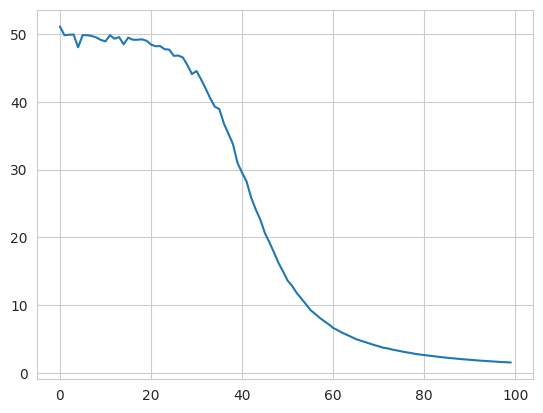

In [13]:
indices = np.arange(100)
    
losses = []

model.train()
for epoch in range(epochs):

    error = 0
    
    np.random.shuffle(indices)
    for i in indices:

        if data.train_mask[i]:

            # set gradients to zero
            optimizer.zero_grad()

            # compute loss function for training sample and backpropagate
            output = model(data.x, data.edge_index)
            loss = torch.nn.functional.binary_cross_entropy(output[i], data.y.float()[i])
            loss.backward()

            # update parameters
            optimizer.step()

            error += loss.detach().numpy()

    losses.append(error)

# plot evolution of loss
plt.plot(range(epochs), losses)

In [14]:
model.forward(data.x, data.edge_index)

tensor([[0.0238],
        [0.0249],
        [0.0263],
        [0.0277],
        [0.0292],
        [0.0308],
        [0.0323],
        [0.0335],
        [0.0345],
        [0.0349],
        [0.0348],
        [0.0341],
        [0.0327],
        [0.0310],
        [0.0286],
        [0.0262],
        [0.0238],
        [0.0215],
        [0.0196],
        [0.0180],
        [0.0168],
        [0.0159],
        [0.0154],
        [0.0152],
        [0.0152],
        [0.0155],
        [0.0160],
        [0.0166],
        [0.0172],
        [0.0176],
        [0.0180],
        [0.0185],
        [0.0186],
        [0.0187],
        [0.0186],
        [0.0185],
        [0.0180],
        [0.0179],
        [0.0179],
        [0.0180],
        [0.0222],
        [0.0180],
        [0.0182],
        [0.0185],
        [0.0189],
        [0.0197],
        [0.0202],
        [0.0209],
        [0.0216],
        [0.0228],
        [0.9846],
        [0.9843],
        [0.9840],
        [0.9826],
        [0.9825],
        [0

In [15]:
output = model.forward(data.x, data.edge_index)
# we efficiently map probabilities to classes by rounding values to the 
# nearest integer, i.e. we obtain class 0 for probabilities smaller than 0.5
# and class 1 for probabilities larger than 0.5
prediction = output.round().long()
colors = {}
for v in network.nodes:
    index = network.mapping.to_idx(v)
    if data.val_mask[index]:
        if prediction[index]==0:
            colors[v] = 'blue'
        else:
            colors[v] = 'orange'
    else:
        colors[v] = 'gray'
pp.plot(network, edge_color='gray', node_color=colors);

## Do We Really Need a One-Hot Encoding?

As discussed above, using a one-hot encoding as node features effectively gives every node its own free, independently learnable embedding vector already in the first layer of the GCN, before any message passing even takes place. This raises a legitimate concern: does our classifier actually learn something about the *topology* of the network, or could it simply be memorizing individual node identities via this per-node lookup, which would not generalize to any node outside of the training graph?

To test this, we repeat the exact same classification experiment, but replace the 100-dimensional one-hot encoding with a much lower-dimensional **random** feature vector for every node. Since a low-dimensional random vector does not act as a unique identifier for a node (many nodes may even have very similar values), the GCN can no longer rely on a per-node lookup and has to exploit the actual graph topology (via message passing) to succeed.

In [ ]:
from sklearn.metrics import balanced_accuracy_score

results = {}
for feature_dim in [1, 2, 4, 8, network.n]:
    torch.manual_seed(0)
    if feature_dim == network.n:
        network.data.x = torch.eye(network.n, dtype=torch.float32)
        label = f'one-hot ({network.n}-dim)'
    else:
        network.data.x = torch.rand(network.n, feature_dim)
        label = f'{feature_dim}-dim random'

    transform = torch_geometric.transforms.RandomNodeSplit(split='train_rest', num_val=0.3, num_test=0)
    data = transform(network.data)

    model = GCN(data, out_ch=1, hidden_dim=4)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    indices = np.arange(network.n)

    model.train()
    for epoch in range(100):
        np.random.shuffle(indices)
        for i in indices:
            if data.train_mask[i]:
                optimizer.zero_grad()
                output = model(data.x, data.edge_index)
                loss = torch.nn.functional.binary_cross_entropy(output[i], data.y.float()[i])
                loss.backward()
                optimizer.step()

    output = model.forward(data.x, data.edge_index)
    prediction = output.round().long()
    val_acc = balanced_accuracy_score(data.y[data.val_mask].cpu().numpy(), prediction[data.val_mask].cpu().numpy())
    results[label] = val_acc
    print(f'{label:>20}: validation balanced accuracy = {val_acc:.3f}')

The exact numbers vary a bit between runs (this is a small, 100-node graph trained with plain SGD for a fixed, fairly small number of epochs, so individual results are noisy), but the overall pattern is clear: already with a handful of random input dimensions, dramatically fewer than the 100 dimensions required for a one-hot encoding, the GCN reaches an accuracy that is close to (and sometimes on par with) the one-hot baseline. A single random dimension is occasionally enough to beat chance level, but is not reliable; by around 8 random dimensions, performance consistently approaches the one-hot result.

This confirms that the classification signal is coming from the *topology* of the graph, propagated through message passing, and not from memorized per-node identities: a low-dimensional random vector cannot possibly serve as a unique lookup key for all 100 nodes, so the only way for the model to succeed is by aggregating and comparing feature information along the edges of the graph. A one-hot encoding is a convenient choice exactly because it requires no real attribute data and trivially provides every node with a distinct input, but as discussed above this comes at the cost of not scaling to large graphs and not generalizing to nodes outside of the training graph. Low-dimensional random features avoid both of these problems, though in practice we of course prefer real, informative node attributes whenever they are available, as we will see in the next notebook.

## Viusalizing feature maps

We can visualize the latent representations generated by the first hidden layer of our model.

In [16]:
embedding = model.input_to_hidden.forward(data.x, data.edge_index)
print(embedding)

tensor([[ 8.9391e-03, -2.2609e-01,  9.1122e-01, -6.7302e-01],
        [-9.3144e-04, -2.1945e-01,  8.8990e-01, -6.5721e-01],
        [-6.4138e-03, -1.9792e-01,  8.8384e-01, -6.4892e-01],
        [-1.2696e-02, -1.9601e-01,  8.6196e-01, -6.3525e-01],
        [-2.2999e-02, -1.8799e-01,  8.5461e-01, -6.2395e-01],
        [-2.4233e-02, -1.8324e-01,  8.3198e-01, -6.1992e-01],
        [-2.1184e-02, -1.8203e-01,  8.1930e-01, -5.9903e-01],
        [-2.0777e-02, -1.9746e-01,  8.0266e-01, -5.8385e-01],
        [-1.4105e-02, -1.9307e-01,  7.9802e-01, -5.7266e-01],
        [-1.8710e-02, -1.8945e-01,  7.7268e-01, -5.6084e-01],
        [-1.9983e-02, -2.0887e-01,  7.8347e-01, -5.5641e-01],
        [-2.5296e-02, -2.2010e-01,  7.8208e-01, -5.6735e-01],
        [-2.8164e-02, -2.2412e-01,  7.8847e-01, -5.6886e-01],
        [-1.3633e-02, -2.2488e-01,  8.1489e-01, -5.8334e-01],
        [-6.7048e-04, -2.4916e-01,  8.3960e-01, -6.0749e-01],
        [-3.7635e-03, -2.6296e-01,  8.6884e-01, -6.2287e-01],
        

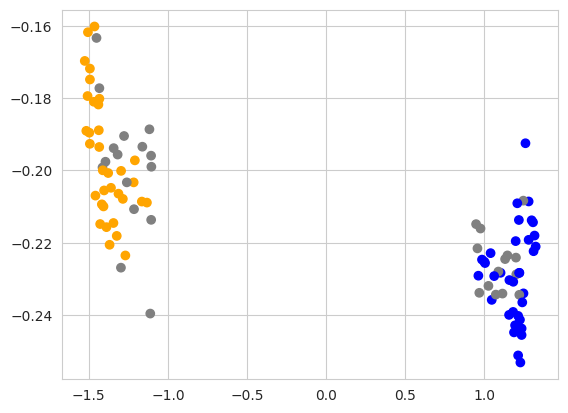

In [17]:
svd = TruncatedSVD()

low_dim = svd.fit_transform(embedding.detach().numpy())

colors = {}
for v in network.nodes:
    index = network.mapping.to_idx(v)   
    if data.val_mask[index]:
        colors[index] = 'grey'
    else:
        if data.y[index] == 0:
            colors[index] = 'blue'
        else:
            colors[index] = 'orange'

plt.scatter(low_dim[:,0], low_dim[:,1], c=colors.values());

## Application to network with non-linear pattern in latent space

We can now use this model to classify nodes in a synthetic example network generated based on a non-linear pattern in a two-dimensional latent space. We reuse the example from Lecture 09, i.e. we generate network based on the circles data set in sklearn.

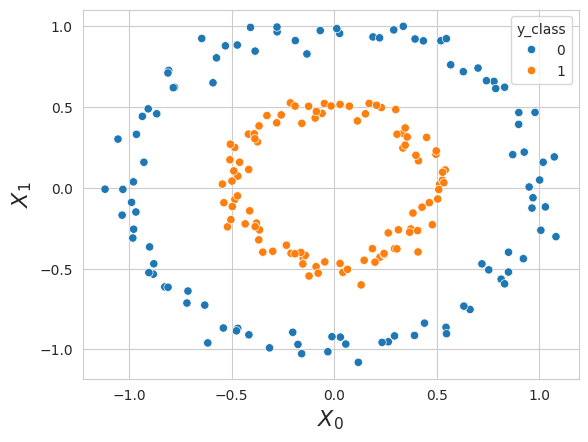

In [18]:
x, c = make_circles(n_samples=200, noise = 0.05, factor = 0.5)
data = pd.DataFrame( {'x0': x[:,0], 'x1': x[:,1], 'y_class': c })

sns.scatterplot(x='x0', y='x1', data=data, hue='y_class')
plt.xlabel(r'$X_0$', fontsize=16)
plt.ylabel(r'$X_1$', fontsize=16);

In [19]:
def euclidean_dist(x, y):
    return np.linalg.norm(x-y)

def soft_rule(dist, **kwargs):
    p = kwargs['beta'] * np.exp(-dist/kwargs['alpha'])
    if np.random.random() <= p:
        return True
    else:
        return False

In [20]:
nodes = []
pos = {}
g = {}
cluster = []

for i, row in data.iterrows():
    nodes.append(str(i))
    pos[str(i)] = np.array([row['x0'], row['x1']])
    g[str(i)] = c[i]
    cluster.append(torch.tensor([c[i]]))
edges = []
for v in nodes:
    for w in nodes:
        if soft_rule(euclidean_dist(pos[v], pos[w]), alpha=0.05, beta=50) and v != w:
            edges.append((v, w))
net = pp.Graph.from_edge_list(edges).to_undirected()
net.data.y = torch.tensor(cluster).unsqueeze_(-1)
net.data.x = torch.eye(net.n, dtype=torch.float32)
print(net.data)

Data(edge_index=[2, 2390], num_nodes=200, node_sequence=[200, 1], y=[200, 1], x=[200, 200])


In [21]:
colors = {}
colors[0] = 'CornflowerBlue'
colors[1] = 'orange'
for v in nodes:
    colors[v] = colors[g[v]]
pp.plot(net, edge_color='grey', node_color = colors);

In [22]:
transform = torch_geometric.transforms.RandomNodeSplit(split='train_rest', num_val=0.3, num_test=0)
data = transform(net.data)

In [23]:
model = GCN(net.data, out_ch=1, hidden_dim=4)

epochs = 100
lrn_rate = 0.1

optimizer = torch.optim.SGD(model.parameters(), lr=lrn_rate)

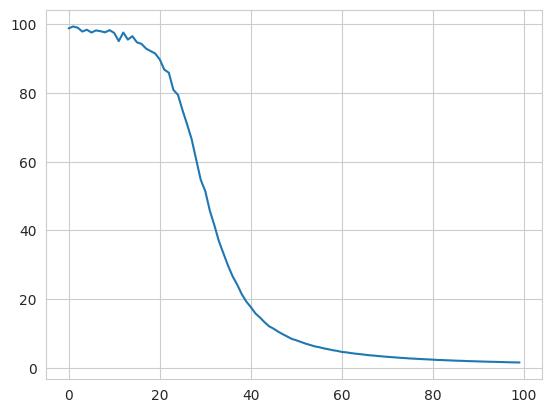

In [24]:
indices = np.arange(net.n)
    
losses = []

model.train()
for epoch in range(epochs):

    error = 0
    
    np.random.shuffle(indices)
    for i in indices:

        if data.train_mask[i]:

            # set gradients to zero
            optimizer.zero_grad()

            # compute loss function for training sample and backpropagate
            output = model(net.data.x, net.data.edge_index)
            loss = torch.nn.functional.binary_cross_entropy(output[i], data.y.float()[i])
            loss.backward()

            # update parameters
            optimizer.step()

            error += loss.detach().numpy()

    losses.append(error)

# plot evolution of loss
plt.plot(range(epochs), losses);

In [25]:
output = model.forward(net.data.x, net.data.edge_index)
# we efficiently map probabilities to classes by rounding values to the 
# nearest integer, i.e. we obtain class 0 for probabilities smaller than 0.5
# and class 1 for probabilities larger than 0.5
prediction = output.round().long()
node_cols = {}
for v in net.nodes:
    index = net.mapping.to_idx(v)
    if data.val_mask[index]:
        node_cols[v] = colors[prediction[index].item()]
    else:
        node_cols[v] = 'gray'
pp.plot(net, edge_color='gray', node_color=node_cols);

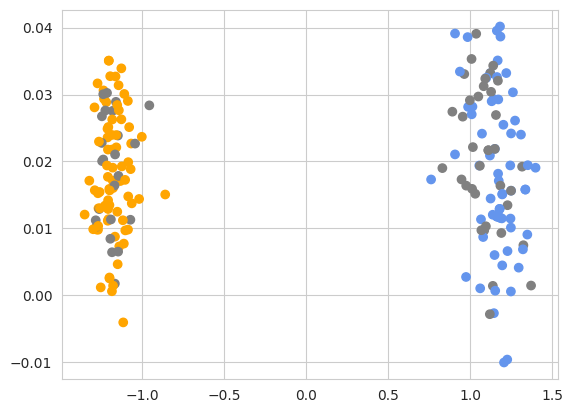

In [28]:
embedding = model.input_to_hidden.forward(data.x, data.edge_index)
svd = TruncatedSVD()

low_dim = svd.fit_transform(embedding.detach().numpy())

color_points = {}
for v in net.nodes:
    index = net.mapping.to_idx(v)
    if data.val_mask[index]:
        color_points[index] = 'grey'
    else:
        color_points[index] = colors[net.data.y[index].item()]

plt.scatter(low_dim[:,0], low_dim[:,1], c=color_points.values())

## Application to empirical network

In [ ]:
karate = pp.io.read_netzschleuder_graph(name='karate', network='78')
karate.data.y = torch.tensor(karate.data.node_groups-1, dtype=torch.float)
karate.data.y.unsqueeze_(-1)
karate.data.x = torch.eye(karate.n, dtype=torch.float32)
print(karate)
pp.plot(karate, edge_color='gray',  node_color=[karate["node_groups", v].item() for v in karate.nodes])

In [34]:
transform = torch_geometric.transforms.RandomNodeSplit(split='train_rest', num_val=0.3, num_test=0)
data = transform(karate.data)

In [37]:
model = GCN(data, out_ch=1, hidden_dim=4)

epochs = 200
lrn_rate = 0.1

optimizer = torch.optim.SGD(model.parameters(), lr=lrn_rate)

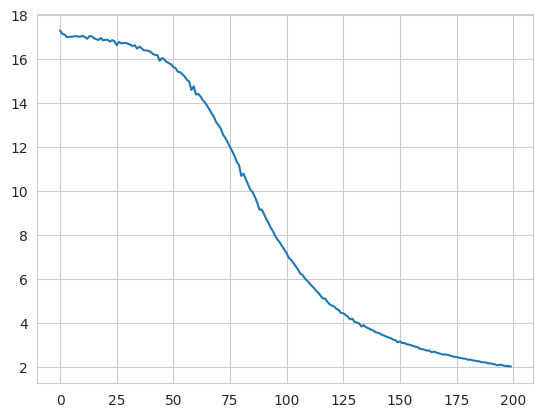

In [38]:
indices = np.arange(karate.n)
    
losses = []

model.train()
for epoch in range(epochs):

    error = 0
    
    np.random.shuffle(indices)
    for i in indices:

        if data.train_mask[i]:

            # set gradients to zero
            optimizer.zero_grad()

            # compute loss function for training sample and backpropagate
            output = model(data.x, data.edge_index)
            loss = torch.nn.functional.binary_cross_entropy(output[i], data.y[i])
            loss.backward()

            # update parameters
            optimizer.step()

            error += loss.detach().numpy()

    losses.append(error)

# plot evolution of loss
plt.plot(range(epochs), losses);

In [39]:
output = model.forward(data.x, data.edge_index)
# we efficiently map probabilities to classes by rounding values to the 
# nearest integer, i.e. we obtain class 0 for probabilities smaller than 0.5
# and class 1 for probabilities larger than 0.5
prediction = output.round().long()
node_cols = {}
for v in karate.nodes:
    index = karate.mapping.to_idx(v)
    if data.val_mask[index]:
        #print(output[index])
        #print(decision(output[index]))
        if prediction[index]==0:
            node_cols[v] = 'CornflowerBlue'
        else:
            node_cols[v] = 'orange'
    else:
        node_cols[v] = 'gray'
pp.plot(karate, edge_color='gray', node_color=node_cols)

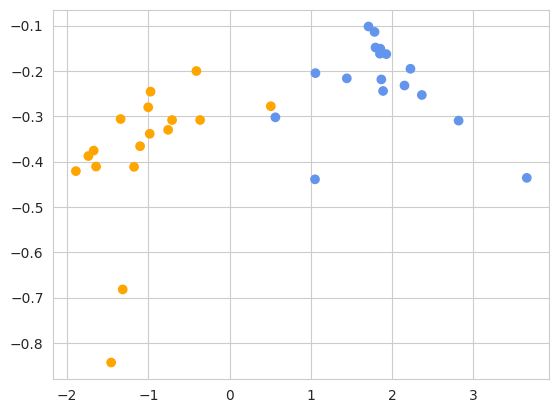

In [40]:
embedding = model.input_to_hidden.forward(data.x, data.edge_index)

low_dim = TruncatedSVD().fit_transform(embedding.detach().numpy())

colors = {}
for v in karate.nodes:
    index = karate.mapping.to_idx(v)
    if data.y[index].item() == 0:
        colors[index] = 'CornflowerBlue'
    else:
        colors[index] = 'orange'

plt.scatter(low_dim[:,0], low_dim[:,1], c=colors.values());